#  Symbolic Conditioned Generation 



## 1. Setup


In [1]:
from __future__ import annotations

import json
import logging
import math
import os
import re
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np

try:
    from IPython.display import Audio, Image, Markdown, display
except Exception:  # plain Python fallback
    Audio = Image = Markdown = None
    def display(value):
        print(value)

# Find project root robustly.
CANDIDATES = [Path.cwd(), Path.cwd().parent, Path('/mntdatalora/src/ScoreVision-MIDI')]
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'configs').exists() and (p / 'models').exists()), Path.cwd())
os.chdir(PROJECT_ROOT)
for import_path in [PROJECT_ROOT, PROJECT_ROOT / 'evaluation']:
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
NOTEBOOK_OUTPUT_DIR = OUTPUT_ROOT / 'submission_notebook'
DEMO_DIR = NOTEBOOK_OUTPUT_DIR / 'five_test_examples'
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEMO_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('Notebook outputs:', NOTEBOOK_OUTPUT_DIR)

PROJECT_ROOT: /mntdatalora/src/ScoreVision-MIDI
Notebook outputs: /mntdatalora/src/ScoreVision-MIDI/outputs/submission_notebook


## 2. Optional Google Drive Weights

The local machine already has the trained weights. In Colab, paste your Google Drive links or file IDs below. The notebook will use local weights if they exist; otherwise it will download from Drive.

Expected local checkpoint paths:

- CRNN: `outputs/scorevision_grandstaff_bekrn_crnn_ddp_b12_bucketed/weights/best.pt`
- CNNT: `outputs/scorevision_grandstaff_bekrn_cnnt_ddp_b2/weights/best.pt`

In [2]:
# Paste external checkpoint links here if running somewhere without local weights.
CRNN_GDRIVE = 'https://ucsdcloud-my.sharepoint.com/:u:/g/personal/vmoparthi_ucsd_edu/IQARdwGGIWSvSpVsfoJ4j7T_AV_J1QWTNbnHvKbNM00RRz4?e=hpP6dj'  # example: 'https://drive.google.com/file/d/.../view?usp=sharing'
CNNT_GDRIVE = 'https://ucsdcloud-my.sharepoint.com/:u:/g/personal/vmoparthi_ucsd_edu/IQCImKoE6K6lR6rOe2Ma0wdDAUIg-q_7-uy03q5FDV1nszE?e=XLhKy9'  # example: 'https://drive.google.com/file/d/.../view?usp=sharing'

MODEL_SPECS = {
    'CRNN': {
        'config': PROJECT_ROOT / 'configs' / 'score_unfolding.yaml',
        'checkpoint': PROJECT_ROOT / 'outputs' / 'scorevision_grandstaff_bekrn_crnn_ddp_b12_bucketed' / 'weights' / 'best.pt',
        'gdrive': CRNN_GDRIVE,
    },
    'CNNT': {
        'config': PROJECT_ROOT / 'configs' / 'score_unfolding_cnnt.yaml',
        'checkpoint': PROJECT_ROOT / 'outputs' / 'scorevision_grandstaff_bekrn_cnnt_ddp_b2' / 'weights' / 'best.pt',
        'gdrive': CNNT_GDRIVE,
    },
}

def ensure_gdown():
    try:
        import gdown  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])


def checkpoint_download_url(link_or_id: str) -> str:
    value = str(link_or_id).strip()
    if not value:
        return ''
    if value.startswith('http'):
        if 'sharepoint.com' in value and 'download=1' not in value:
            separator = '&' if '?' in value else '?'
            return f'{value}{separator}download=1'
        return value
    return f'https://drive.google.com/uc?id={value}'


def download_checkpoint_link(link_or_id: str, checkpoint: Path) -> None:
    value = str(link_or_id).strip()
    url = checkpoint_download_url(value)
    if 'drive.google.com' in value or not value.startswith('http'):
        ensure_gdown()
        import gdown

        gdown.download(url, str(checkpoint), fuzzy=True, quiet=False)
        return

    import urllib.request

    with urllib.request.urlopen(url) as response, checkpoint.open('wb') as handle:
        shutil.copyfileobj(response, handle)


def ensure_checkpoint(model_name: str) -> Path:
    spec = MODEL_SPECS[model_name]
    checkpoint = Path(spec['checkpoint'])
    if checkpoint.exists():
        print(f'{model_name}: using local checkpoint {checkpoint}')
        return checkpoint

    link = str(spec.get('gdrive') or '').strip()
    if not link:
        raise FileNotFoundError(
            f'{model_name} checkpoint not found at {checkpoint}. Paste an external checkpoint link/file ID in {model_name}_GDRIVE.'
        )

    checkpoint.parent.mkdir(parents=True, exist_ok=True)
    print(f'{model_name}: downloading checkpoint to {checkpoint}')
    download_checkpoint_link(link, checkpoint)
    if not checkpoint.exists():
        raise FileNotFoundError(f'Download did not create {checkpoint}')
    return checkpoint

for model_name in MODEL_SPECS:
    path = MODEL_SPECS[model_name]['checkpoint']
    print(model_name, 'checkpoint exists:', path.exists(), '|', path)

CRNN checkpoint exists: True | /mntdatalora/src/ScoreVision-MIDI/outputs/scorevision_grandstaff_bekrn_crnn_ddp_b12_bucketed/weights/best.pt
CNNT checkpoint exists: True | /mntdatalora/src/ScoreVision-MIDI/outputs/scorevision_grandstaff_bekrn_cnnt_ddp_b2/weights/best.pt


## Exact Best Checkpoints for Inference

Use these exact `best.pt` files for the inference/demo cells. These are the best validation-SER checkpoints that were evaluated on the full GrandStaff test split.

| Model | Best checkpoint to keep/upload | Best epoch | Best validation SER | Config |
|---|---|---:|---:|---|
| CRNN | `outputs/scorevision_grandstaff_bekrn_crnn_ddp_b12_bucketed/weights/best.pt` | 81 | 5.8109 | `configs/score_unfolding.yaml` |
| CNNT | `outputs/scorevision_grandstaff_bekrn_cnnt_ddp_b2/weights/best.pt` | 70 | 5.1627 | `configs/score_unfolding_cnnt.yaml` |

For external notebook/runtime use, upload those two checkpoint files and paste their SharePoint/Google Drive links into `CRNN_GDRIVE` and `CNNT_GDRIVE` in the next code cell. The notebook also needs the repo configs and vocabulary files under `outputs/vocab/`.

## 3. Dataset and Preprocessing

The dataset is the local GrandStaff split used for both CRNN and CNNT. The preprocessing pipeline matches the training code:

1. Read partition files: `train.txt`, `val.txt`, `test.txt`.
2. Resolve each row to a `.bekrn` transcription.
3. Tokenize BEKRN using the project tokenizer: spaces become `<s>`, tabs become `<t>`, line breaks become `<b>`.
4. Read the clean `.jpg` image as grayscale. The trained CRNN/CNNT configs set `load_distorted: false`.
5. Resize with ratio `1.0`, rotate clockwise, cache as `.npy`.
6. Normalize image tensors with `image / 255.0`, pad image/target batches, and train/evaluate with CTC.

In [3]:
DATA_REPORT_DIR = PROJECT_ROOT / 'outputs' / 'visualiser' / 'data_preprocessing'
SUMMARY_JSON = DATA_REPORT_DIR / 'dataset_summary.json'

if not SUMMARY_JSON.exists():
    print('Data summary not found; generating it now. This scans all GrandStaff entries and can take time.')
    subprocess.check_call([sys.executable, 'visualiser/analyse_grandstaff_data.py', '--workers', '16'])

summary = json.loads(SUMMARY_JSON.read_text())
stats = summary['total_statistics']
rows = [
    ('Total samples', f"{stats['samples']:,}"),
    ('Cached model-input images', f"{stats['cached_npy']:,}"),
    ('Vocabulary size', f"{stats['vocab_size']:,}"),
    ('Total target tokens', f"{stats['total_tokens']:,}"),
    ('Median target length', f"{stats['token_length']['median']:,} tokens"),
    ('p95 target length', f"{stats['token_length']['p95']:,} tokens"),
    ('Max target length', f"{stats['token_length']['max']:,} tokens"),
    ('Median cached height', f"{stats['cache_height']['median']:,} px"),
    ('Median cached width', f"{stats['cache_width']['median']:,} px"),
]
md_table = '| Item | Value |\n|---|---:|\n' + '\n'.join(f'| {k} | {v} |' for k, v in rows)
display(Markdown(md_table) if Markdown else md_table)

| Item | Value |
|---|---:|
| Total samples | 53,882 |
| Cached model-input images | 53,882 |
| Vocabulary size | 187 |
| Total target tokens | 19,806,274 |
| Median target length | 334 tokens |
| p95 target length | 682 tokens |
| Max target length | 1,716 tokens |
| Median cached height | 724 px |
| Median cached width | 256 px |

## 4. Model Architecture

Both models solve the same image-conditioned symbolic generation problem:

```text
score image -> CNN encoder -> sequence decoder -> CTC greedy decode -> BEKRN/KERN sequence
```

Shared encoder:

- Five convolutional blocks with channels `1 -> 32 -> 64 -> 128 -> 256 -> 512`.
- Strides `(1,1), (2,2), (2,2), (2,2), (2,1)`.
- Four depthwise-separable residual convolution blocks at 512 channels.
- Final encoder reduction constants from the repo: height reduction `16`, width reduction `8`, output channels `512`.

Decoder difference:

- **CRNN:** bidirectional LSTM decoder with hidden size 256, then linear projection to the vocabulary plus CTC blank.
- **CNNT:** 1D positional encoding plus one Transformer encoder layer with `d_model=512`, `nhead=8`, feed-forward dimension `1024`, then linear projection to vocabulary plus CTC blank.

In [5]:
import torch
from models.score_unfolding import build_model, compute_encoder_output_hw, compute_unfolded_length
from utils.config import load_yaml_config, resolve_path
from utils.vocabulary import load_or_create_vocabulary


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

arch_rows = []
for model_name, spec in MODEL_SPECS.items():
    config = load_yaml_config(spec['config'])
    vocab_dir = resolve_path(config['vocab']['directory'], PROJECT_ROOT)
    w2i, i2w = load_or_create_vocabulary(None, vocab_dir=vocab_dir, name=config['vocab']['name'], sort_tokens=False, logger=logging.getLogger('vocab'))
    out_size = len(w2i) + 1  # +1 CTC blank
    # CNNT config stores exact max dimensions. CRNN can use the same maximum for architecture reporting.
    max_height = int(config['data'].get('max_height') or summary['total_statistics']['cache_height']['max'])
    max_width = int(config['data'].get('max_width') or summary['total_statistics']['cache_width']['max'])
    model = build_model(
        model_name=config['model']['name'],
        max_width=max_width,
        max_height=max_height,
        in_channels=int(config['model']['in_channels']),
        out_size=out_size,
        dropout=float(config['model'].get('dropout', 0.4)),
        max_len=config['model'].get('max_len'),
        pretrain_path=config['model'].get('pretrain_path'),
    )
    total, trainable = count_parameters(model)
    enc_h, enc_w = compute_encoder_output_hw(max_height, max_width)
    arch_rows.append((model_name, config['model']['name'], f'{total:,}', f'{trainable:,}', f'{max_height}x{max_width}', f'{enc_h}x{enc_w}', f'{enc_h * enc_w:,}', out_size))

md_table = '| Model | Config name | Params | Trainable | Max input HxW | Encoded HxW | CTC time steps | Output classes |\n|---|---|---:|---:|---:|---:|---:|---:|\n'
md_table += '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in arch_rows)
display(Markdown(md_table) if Markdown else md_table)

| Model | Config name | Params | Trainable | Max input HxW | Encoded HxW | CTC time steps | Output classes |
|---|---|---:|---:|---:|---:|---:|---:|
| CRNN | CRNN | 12,742,525 | 12,742,525 | 3056x256 | 191x32 | 6,112 | 189 |
| CNNT | CNNT | 13,268,349 | 13,268,349 | 3056x256 | 191x32 | 6,112 | 189 |

## 5. Evaluation Metrics

The paper-style evaluation uses three normalized Levenshtein metrics:

- **CER:** character error rate after character-level parsing.
- **SER:** symbol error rate after BEKRN/KERN token parsing.
- **LER:** line error rate after line-level parsing.

For the final test-set numbers below, the checkpoint was decoded on the local GrandStaff `test.txt` split with 7,661 samples.

### Final GrandStaff Test Metrics

These values are already computed from checkpoint inference on the exact local GrandStaff test split (`7,661` samples). They are shown here as fixed Markdown values so the table is visible in the submitted notebook without rerunning evaluation.

| Model | Test samples | CER | SER | LER | Checkpoint epoch | Prediction output |
|---|---:|---:|---:|---:|---:|---|
| CRNN | 7,661 | 4.3678 | 7.2036 | 19.1032 | 81 | `evaluation/runs/crnn_test/hyp` |
| CNNT | 7,661 | 3.9117 | 6.3623 | 16.3517 | 70 | `evaluation/runs/cnnt_test/hyp` |

**Reading:** CNNT is the stronger final checkpoint on all three metrics. The CER/SER/LER values above come from the same paper-style evaluator used in `evaluation/ctc_eval.py`.

### Loss and Validation Curves

![Loss versus validation SER](../outputs/visualiser/training_curves/loss_vs_validation_ser.png)

![Validation metrics comparison](../outputs/visualiser/training_curves/validation_metrics_comparison.png)

## 6. Five Test-Example Inference Demo

This section runs checkpoint inference on the first five GrandStaff test samples. It writes symbolic outputs to:

```text
outputs/submission_notebook/five_test_examples/{MODEL}/hyp/*.krn
outputs/submission_notebook/five_test_examples/{MODEL}/gt/*.krn
outputs/submission_notebook/five_test_examples/{MODEL}/images/*.jpg
```

Use `MODEL_FOR_DEMO = 'CNNT'` for the best final test result, or switch it to `'CRNN'` to demonstrate the baseline model.

In [6]:
MODEL_FOR_DEMO = 'CNNT'  # choose 'CNNT' or 'CRNN'
NUM_DEMO_SAMPLES = 5
DEVICE_NAME = 'auto'  # 'auto', 'cpu', or 'cuda:0'

In [7]:
from torch.utils.data import DataLoader

from evaluation.ctc_eval import build_eval_dataset, infer_model_hw, resolve_eval_device, _strip_module_prefix
from models.score_unfolding import build_model
from utils.data import ctc_collate
from utils.decoding import greedy_decode_ctc
from utils.transcription import tokens_to_kern

logger = logging.getLogger('submission_demo')
logger.setLevel(logging.INFO)


def build_demo_model(model_name: str):
    spec = MODEL_SPECS[model_name]
    checkpoint_path = ensure_checkpoint(model_name)
    config = load_yaml_config(spec['config'])
    config['data']['max_samples'] = NUM_DEMO_SAMPLES

    # If the image cache is absent in a fresh Colab run, fall back to raw image preprocessing.
    cache_dir = resolve_path(config['data'].get('image_cache_dir'), PROJECT_ROOT)
    if cache_dir is None or not Path(cache_dir).exists():
        config['data']['image_cache_dir'] = None
        config['data']['metadata_cache_dir'] = None

    dataset = build_eval_dataset(config=config, split='test', project_root=PROJECT_ROOT, logger=logger)
    vocab_dir = resolve_path(config['vocab']['directory'], PROJECT_ROOT)
    w2i, i2w = load_or_create_vocabulary(None, vocab_dir=vocab_dir, name=config['vocab']['name'], sort_tokens=False, logger=logger)
    dataset.set_dictionaries(w2i, i2w)

    model_key = str(config['model']['name']).upper()
    max_height, max_width = infer_model_hw(config, model_key, dataset)
    blank_idx = len(i2w)
    out_size = len(w2i) + 1
    model = build_model(
        model_name=model_key,
        max_width=max_width,
        max_height=max_height,
        in_channels=int(config['model']['in_channels']),
        out_size=out_size,
        dropout=float(config['model'].get('dropout', 0.4)),
        max_len=config['model'].get('max_len'),
        pretrain_path=config['model'].get('pretrain_path'),
    )

    device = resolve_eval_device(DEVICE_NAME)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(_strip_module_prefix(state_dict), strict=True)
    model.to(device)
    model.eval()
    return model, dataset, i2w, blank_idx, device, checkpoint_path


def run_five_example_demo(model_name: str):
    model, dataset, i2w, blank_idx, device, checkpoint_path = build_demo_model(model_name)
    model_dir = DEMO_DIR / model_name.lower()
    hyp_dir = model_dir / 'hyp'
    gt_dir = model_dir / 'gt'
    image_dir = model_dir / 'images'
    for directory in [hyp_dir, gt_dir, image_dir]:
        directory.mkdir(parents=True, exist_ok=True)

    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=ctc_collate)
    rows = []
    with torch.no_grad():
        for idx, batch in enumerate(loader):
            images, targets, input_lengths, target_lengths = batch
            images = images.to(device)
            targets = targets.to(device)
            predictions = model(images)
            decoded, target_tokens = greedy_decode_ctc(
                predictions,
                targets,
                input_lengths.cpu(),
                target_lengths.cpu(),
                i2w,
                blank_idx,
            )
            hyp_text = tokens_to_kern(decoded[0])
            gt_text = tokens_to_kern(target_tokens[0])
            hyp_path = hyp_dir / f'{idx}.krn'
            gt_path = gt_dir / f'{idx}.krn'
            hyp_path.write_text(hyp_text, encoding='utf-8')
            gt_path.write_text(gt_text, encoding='utf-8')

            transcription_path = dataset.samples[idx][0]
            image_path = transcription_path.with_suffix('.jpg')
            copied_image = image_dir / f'{idx}_{image_path.name}'
            if image_path.exists():
                shutil.copy2(image_path, copied_image)

            rows.append({
                'index': idx,
                'input_image': copied_image,
                'hyp': hyp_path,
                'gt': gt_path,
                'relative_sample': str(transcription_path.relative_to(PROJECT_ROOT / 'data')) if transcription_path.is_relative_to(PROJECT_ROOT / 'data') else str(transcription_path),
            })
    print(f'Checkpoint used: {checkpoint_path}')
    print(f'Wrote demo files to: {model_dir}')
    return rows

example_rows = run_five_example_demo(MODEL_FOR_DEMO)

md_table = '| # | Input sample | Prediction | Ground truth |\n|---:|---|---|---|\n'
for row in example_rows:
    md_table += f"| {row['index']} | `{row['relative_sample']}` | `{row['hyp'].relative_to(PROJECT_ROOT)}` | `{row['gt'].relative_to(PROJECT_ROOT)}` |\n"
display(Markdown(md_table) if Markdown else md_table)

CNNT: using local checkpoint /mntdatalora/src/ScoreVision-MIDI/outputs/scorevision_grandstaff_bekrn_cnnt_ddp_b2/weights/best.pt


Checkpoint used: /mntdatalora/src/ScoreVision-MIDI/outputs/scorevision_grandstaff_bekrn_cnnt_ddp_b2/weights/best.pt
Wrote demo files to: /mntdatalora/src/ScoreVision-MIDI/outputs/submission_notebook/five_test_examples/cnnt


| # | Input sample | Prediction | Ground truth |
|---:|---|---|---|
| 0 | `grandstaff_dataset/grandstaff/beethoven/piano-sonatas/sonata01-1/original_m-0-5.bekrn` | `outputs/submission_notebook/five_test_examples/cnnt/hyp/0.krn` | `outputs/submission_notebook/five_test_examples/cnnt/gt/0.krn` |
| 1 | `grandstaff_dataset/grandstaff/beethoven/piano-sonatas/sonata01-1/original_m-10-15.bekrn` | `outputs/submission_notebook/five_test_examples/cnnt/hyp/1.krn` | `outputs/submission_notebook/five_test_examples/cnnt/gt/1.krn` |
| 2 | `grandstaff_dataset/grandstaff/beethoven/piano-sonatas/sonata01-1/original_m-100-105.bekrn` | `outputs/submission_notebook/five_test_examples/cnnt/hyp/2.krn` | `outputs/submission_notebook/five_test_examples/cnnt/gt/2.krn` |
| 3 | `grandstaff_dataset/grandstaff/beethoven/piano-sonatas/sonata01-1/original_m-110-115.bekrn` | `outputs/submission_notebook/five_test_examples/cnnt/hyp/3.krn` | `outputs/submission_notebook/five_test_examples/cnnt/gt/3.krn` |
| 4 | `grandstaff_dataset/grandstaff/beethoven/piano-sonatas/sonata01-1/original_m-115-120.bekrn` | `outputs/submission_notebook/five_test_examples/cnnt/hyp/4.krn` | `outputs/submission_notebook/five_test_examples/cnnt/gt/4.krn` |


### Example 0

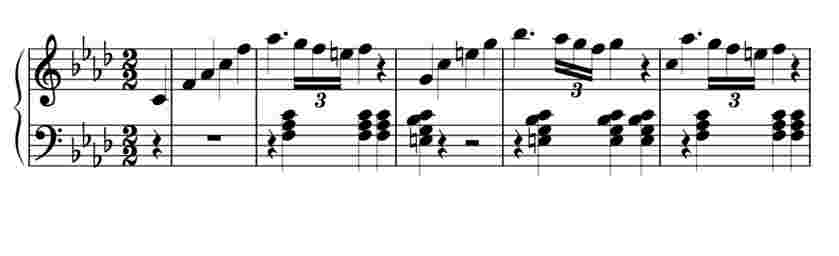

**Prediction preview**

```text
**ekern_1.0	**ekern_1.0
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
4r	4c
=	=
1r	4f
.	4a-
.	4cc
.	4ff
=	=
4r	4.aa-
4F 4A- 4c	.
.	24ggLL
.	24ff
.	24eeJJ
4F 4A- 4c	4ff
4F 4A- 4c	4r
```

**Ground-truth preview**

```text
**ekern_1.0	**ekern_1.0
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
4r	4c
=	=
1r	4f
.	4a-
.	4cc
.	4ff
=	=
4r	4.aa-
4F 4A- 4c	.
.	24ggLL
.	24ff
.	24eeJJ
4F 4A- 4c	4ff
4F 4A- 4c	4r
```

### Example 1

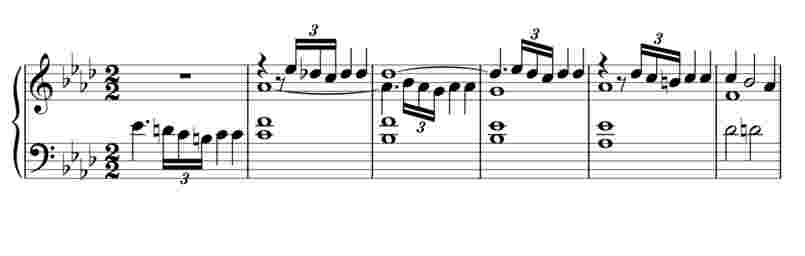

**Prediction preview**

```text
**ekern_1.0	**ekern_1.0
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4.e-	1r
24dLL	.
24c	.
24BJJ	.
4c	.
4c	.
=	=
*	*^
1c 1f	4r	1a-
.	8r
.	24LL	ee-L[	.
.	24dd-	.
.	24ccJJ	.
```

**Ground-truth preview**

```text
**ekern_1.0	**ekern_1.0
*clefF4	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4.e-	1r
24dLL	.
24c	.
24BJJ	.
4c	.
4c	.
=	=
*	*^
1c 1f	4r	1a-[
.	8r	.
.	24ee-LL	.
.	24dd-X	.
.	24ccJJ	.
```

### Example 2

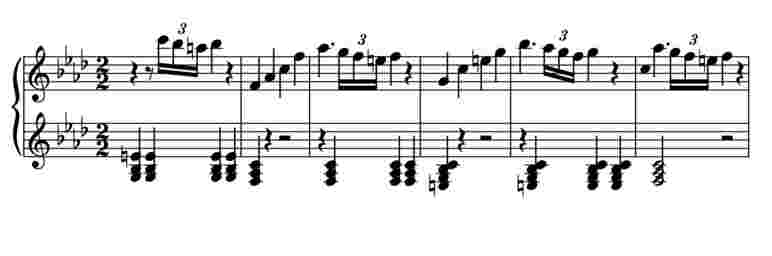

**Prediction preview**

```text
**ekern_1.0	**ekern_1.0
*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4G 4B- 4e	4r
4G 4B- 4e	8r
.	16cccLL
.	24bb-
.	24aaJJ
4G 4B- 4e	4bb-
4G 4B- 4e	4r
=	=
4F 4A- 4c	4f
4r	4a-
2r	4cc
.	4ff
=	=
```

**Ground-truth preview**

```text
**ekern_1.0	**ekern_1.0
*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4G 4B- 4e	4r
4G 4B- 4e	8r
.	24cccLL
.	24bb-
.	24aaJJ
4G 4B- 4e	4bb-
4G 4B- 4e	4r
=	=
4F 4A- 4c	4f
4r	4a-
2r	4cc
.	4ff
=	=
```

### Example 3

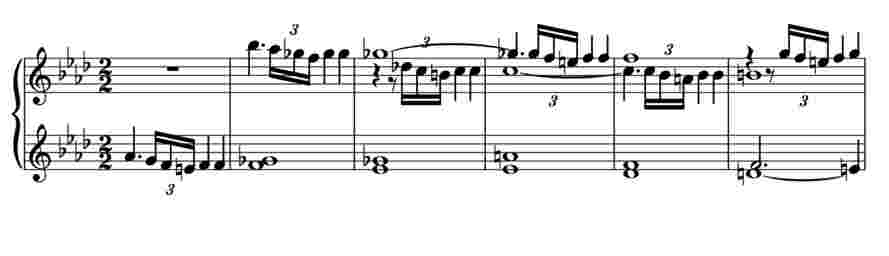

**Prediction preview**

```text
**ekern_1.0	**ekern_1.0
*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4.a-	1r
16gLL	.
24f	.
24eJJ	.
4f	.
4f	.
=	=
1f 1g-	4.bb-
.	2424aa-LL
.	24gg-
.	24ffJJ
.	4gg-
.	4gg-
```

**Ground-truth preview**

```text
**ekern_1.0	**ekern_1.0
*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2
=-	=-
4.a-	1r
24gLL	.
24f	.
24eJJ	.
4f	.
4f	.
=	=
1f 1g-	4.bb-
.	24aa-LL
.	24gg-
.	24ffJJ
.	4gg-
.	4gg-
```

### Example 4

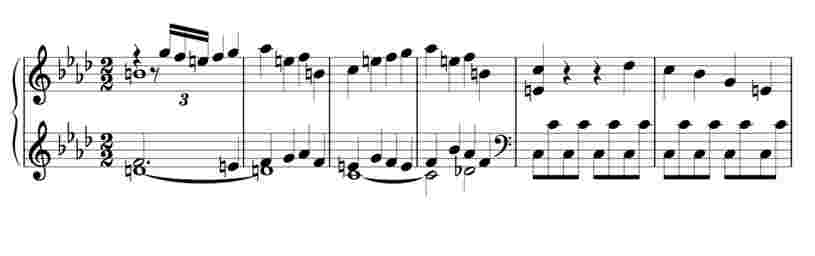

**Prediction preview**

```text
**ekern_1.0	**ekern_1.0
	*^
*clefG2	*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2	*M2/2
=-	=-	=-
*^	*	*
2.f	1d[	4r	1b
.	.	8r
.	.	24ggLL	.
.	.	24ff.
.	.	24eeJJ	.
.	.	4ff	.
.	.	4gg	.
*	*	*v	=
=	=	=
4f	1d]	4aa-
4g	.	4ee
```

**Ground-truth preview**

```text
**ekern_1.0	**ekern_1.0
*	*^
*clefG2	*clefG2	*clefG2
*k[b-e-a-d-]	*k[b-e-a-d-]	*k[b-e-a-d-]
*M2/2	*M2/2	*M2/2
=-	=-	=-
*^	*	*
2.f	1d[	4r	1b
.	.	8r	.
.	.	24ggLL	.
.	.	24ff	.
.	.	24eeJJ	.
.	.	4ff	.
4e	.	4gg	.
*	*	*v	*v
=	=	=
4f	1dnX]	4aa-
4g	.	4ee
```

In [8]:
# Display the five input images and short prediction snippets.
for row in example_rows:
    display(Markdown(f"### Example {row['index']}") if Markdown else f"Example {row['index']}")
    if Path(row['input_image']).exists():
        display(Image(filename=str(row['input_image'])) if Image else row['input_image'])
    hyp_text = Path(row['hyp']).read_text(encoding='utf-8')
    gt_text = Path(row['gt']).read_text(encoding='utf-8')
    display(Markdown('**Prediction preview**\n\n```text\n' + '\n'.join(hyp_text.splitlines()[:18]) + '\n```') if Markdown else hyp_text[:800])
    display(Markdown('**Ground-truth preview**\n\n```text\n' + '\n'.join(gt_text.splitlines()[:18]) + '\n```') if Markdown else gt_text[:800])

## 7. Optional WAV/MP3 Demo Audio

The model output is symbolic text, not audio. For the presentation, the cell below creates a simple audible WAV demo from each predicted KRN file. This is not part of the paper metrics; it is only for presentation playback.

The converter is intentionally simple: it recognizes common KERN note/rest tokens, approximates pitch/duration, and writes a sine-wave WAV. If `ffmpeg` is installed, it also creates MP3 files.

In [9]:
import wave

NOTE_BASE_LOWER = {'c': 60, 'd': 62, 'e': 64, 'f': 65, 'g': 67, 'a': 69, 'b': 71}
NOTE_BASE_UPPER = {'C': 48, 'D': 50, 'E': 52, 'F': 53, 'G': 55, 'A': 57, 'B': 59}


def kern_duration_quarters(token: str) -> float:
    match = re.match(r'^(\d+)(\.*)', token)
    if not match:
        return 1.0
    denom = int(match.group(1))
    duration = 4.0 / max(denom, 1)
    dot_count = len(match.group(2))
    add = duration
    for _ in range(dot_count):
        add *= 0.5
        duration += add
    return duration


def kern_note_to_midi(token: str) -> int | None:
    if 'r' in token or token in {'.', ''} or token.startswith('*') or token.startswith('='):
        return None
    body = re.sub(r'^\d+\.*', '', token)
    letters = re.findall(r'[A-Ga-g]+', body)
    if not letters:
        return None
    name = letters[0]
    letter = name[0]
    if letter.islower():
        pitch = NOTE_BASE_LOWER[letter] + 12 * (len(name) - 1)
    else:
        pitch = NOTE_BASE_UPPER[letter] - 12 * (len(name) - 1)
    # Accidentals in **kern: # is sharp, - is flat.
    pitch += body.count('#')
    pitch -= body.count('-')
    return int(np.clip(pitch, 21, 108))


def kern_to_note_events(kern_text: str, qpm: float = 96.0):
    seconds_per_quarter = 60.0 / qpm
    current = 0.0
    events = []
    for line in kern_text.splitlines():
        if not line.strip() or line.startswith('!'):
            continue
        cells = line.split('\t')
        line_duration_quarters = 0.0
        line_events = []
        for cell in cells:
            cell = cell.strip()
            if not cell or cell == '.' or cell.startswith('*') or cell.startswith('='):
                continue
            # Chords are represented by space-separated note tokens.
            chord_tokens = cell.split()
            duration = max(kern_duration_quarters(tok) for tok in chord_tokens)
            line_duration_quarters = max(line_duration_quarters, duration)
            for tok in chord_tokens:
                pitch = kern_note_to_midi(tok)
                if pitch is not None:
                    line_events.append((pitch, current, current + duration * seconds_per_quarter))
        events.extend(line_events)
        if line_duration_quarters > 0:
            current += line_duration_quarters * seconds_per_quarter
    return events


def synthesize_events_to_wav(events, wav_path: Path, sample_rate: int = 22050):
    wav_path.parent.mkdir(parents=True, exist_ok=True)
    if not events:
        duration = 1.0
        audio = np.zeros(int(sample_rate * duration), dtype=np.float32)
    else:
        duration = max(end for _, _, end in events) + 0.25
        audio = np.zeros(int(sample_rate * duration), dtype=np.float32)
        for pitch, start, end in events:
            start_i = max(0, int(start * sample_rate))
            end_i = min(len(audio), int(end * sample_rate))
            if end_i <= start_i:
                continue
            t = np.arange(end_i - start_i, dtype=np.float32) / sample_rate
            freq = 440.0 * (2.0 ** ((pitch - 69) / 12.0))
            tone = np.sin(2 * np.pi * freq * t)
            envelope = np.ones_like(tone)
            fade = min(len(envelope) // 2, int(0.01 * sample_rate))
            if fade > 0:
                envelope[:fade] *= np.linspace(0, 1, fade)
                envelope[-fade:] *= np.linspace(1, 0, fade)
            audio[start_i:end_i] += 0.08 * tone * envelope
        peak = float(np.max(np.abs(audio)))
        if peak > 0:
            audio = audio / peak * 0.85
    pcm = np.asarray(np.clip(audio, -1.0, 1.0) * 32767, dtype='<i2')
    with wave.open(str(wav_path), 'wb') as handle:
        handle.setnchannels(1)
        handle.setsampwidth(2)
        handle.setframerate(sample_rate)
        handle.writeframes(pcm.tobytes())
    return wav_path


def maybe_convert_wav_to_mp3(wav_path: Path):
    ffmpeg = shutil.which('ffmpeg')
    if ffmpeg is None:
        return None
    mp3_path = wav_path.with_suffix('.mp3')
    subprocess.run([ffmpeg, '-y', '-loglevel', 'error', '-i', str(wav_path), str(mp3_path)], check=False)
    return mp3_path if mp3_path.exists() else None

AUDIO_DIR = DEMO_DIR / MODEL_FOR_DEMO.lower() / 'audio'
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

audio_rows = []
for row in example_rows:
    hyp_text = Path(row['hyp']).read_text(encoding='utf-8')
    events = kern_to_note_events(hyp_text)
    wav_path = synthesize_events_to_wav(events, AUDIO_DIR / f"example_{row['index']}_{MODEL_FOR_DEMO.lower()}_prediction.wav")
    mp3_path = maybe_convert_wav_to_mp3(wav_path)
    audio_rows.append((row['index'], wav_path, mp3_path, len(events)))

md_table = '| # | Note events | WAV | MP3 |\n|---:|---:|---|---|\n'
for idx, wav_path, mp3_path, event_count in audio_rows:
    mp3_text = f'`{mp3_path.relative_to(PROJECT_ROOT)}`' if mp3_path else 'not created'
    md_table += f"| {idx} | {event_count} | `{wav_path.relative_to(PROJECT_ROOT)}` | {mp3_text} |\n"
display(Markdown(md_table) if Markdown else md_table)

# Play the first generated WAV inside the notebook.
if audio_rows and Audio is not None:
    display(Audio(filename=str(audio_rows[0][1])))

| # | Note events | WAV | MP3 |
|---:|---:|---|---|
| 0 | 59 | `outputs/submission_notebook/five_test_examples/cnnt/audio/example_0_cnnt_prediction.wav` | not created |
| 1 | 46 | `outputs/submission_notebook/five_test_examples/cnnt/audio/example_1_cnnt_prediction.wav` | not created |
| 2 | 71 | `outputs/submission_notebook/five_test_examples/cnnt/audio/example_2_cnnt_prediction.wav` | not created |
| 3 | 49 | `outputs/submission_notebook/five_test_examples/cnnt/audio/example_3_cnnt_prediction.wav` | not created |
| 4 | 60 | `outputs/submission_notebook/five_test_examples/cnnt/audio/example_4_cnnt_prediction.wav` | not created |
